# **Early-Warning Model: Stigma Signals and Lead–Lag Forecasting**

## **Introduction**

This notebook develops a **time-aware early-warning model** designed to detect precursor signals that emerge in digital discourse before confirmed H5N1 outbreaks. Using the multi-source outbreak ground truth dataset and daily country-level stigma indicators, the workflow aligns digital behavioral signals with real-world outbreak timelines to evaluate whether fear, urgency, and related narratives rise in advance of official reporting.

To accomplish this, the notebook constructs a complete date × country panel, labels **30-day pre-outbreak windows**, engineers **lagged and rolling emotional features**, and trains a class-weighted logistic regression model to estimate the probability that a given day falls within a pre-outbreak risk period. This approach blends concepts from **digital epidemiology**, **risk amplification theory**, and classical **lead–lag analysis** to explore whether online emotional signals contain predictive value for outbreak surveillance.

---

## **Objectives**

### **1. Merge Digital Stigma Signals with Multi-Source Outbreak Ground Truth**

* Combine daily stigma indicators (fear, urgency, humor) with unified outbreak labels
* Align data across countries and calendar dates
* Create a complete panel regardless of reporting gaps

### **2. Generate Early-Warning Labels**

* Define a **30-day early-warning window** prior to each outbreak
* Tag each date-country pair as:

  * `early_warning = 1` (within 30 days before an outbreak)
  * `early_warning = 0` (no elevated risk detected)

### **3. Engineer Temporal Lead–Lag Features**

* Create **1-day, 3-day, and 7-day lags** for each stigma category
* Generate **7-day rolling averages** to capture sustained emotional patterns
* Structure features to reflect short-term and medium-term behavioral escalation

### **4. Train a Class-Weighted Logistic Regression Model**

* Use `class_weight="balanced"` to counter severe label imbalance
* Fit the model on standardized features
* Output risk probabilities for each date-country pair

### **5. Evaluate Model Performance**

* Report classification metrics at the default 0.5 threshold
* Compute **ROC-AUC** and **PR-AUC** to quantify discriminative ability
* Tune decision thresholds to optimize recall and F1 for early detection

### **6. Produce Actionable Early-Warning Insights**

* Identify whether fear and urgency spikes precede outbreaks
* Assess the predictive importance of different lag windows
* Provide a foundation for more advanced forecasting models (CatBoost, TFT)




In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, precision_recall_curve

In [26]:
# ================================================================
# LOGISTIC REGRESSION EARLY-WARNING MODEL (FEAR + URGENCY ONLY)
# ================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, precision_recall_curve
import matplotlib.pyplot as plt

# ========================
# LOAD DATA
# ========================
gt = pd.read_csv("improved_h5n1_ground_truth.csv")
gt["date"] = pd.to_datetime(gt["date"]).dt.date
gt["date"] = pd.to_datetime(gt["date"])
#gt["country"] = gt["country"].astype(str).strip()

stigma = pd.read_csv("tft/tft_part2_daily_stigma_fixed.csv")
stigma["date"] = pd.to_datetime(stigma["date"])
#stigma["inferred_country"] = stigma["inferred_country"].astype(str).str.strip()

gt["country"] = gt["country"].astype(str).str.strip()
stigma["inferred_country"] = stigma["inferred_country"].astype(str).str.strip()

# ========================
# FULL DAILY GRID
# ========================
all_countries = stigma["inferred_country"].unique()
all_dates = pd.date_range(stigma["date"].min(), stigma["date"].max(), freq="D")

calendar = (
    pd.MultiIndex.from_product([all_dates, all_countries], names=["date","country"])
    .to_frame(index=False)
)

gt_daily = (
    gt.groupby(["date","country"], as_index=False)
      .agg({"fused_outbreak":"max"})
)

gt_full = calendar.merge(gt_daily, on=["date","country"], how="left")
gt_full["fused_outbreak"] = gt_full["fused_outbreak"].fillna(0).astype(int)

# ========================
# EARLY-WARNING LABELING: 30 DAYS BEFORE OUTBREAK
# ========================
early_window = 30
gt_full = gt_full.sort_values(["country","date"])
gt_full["early_warning"] = 0

for c in gt_full["country"].unique():
    df = gt_full[gt_full["country"] == c]
    outbreak_dates = df[df["fused_outbreak"] == 1]["date"].values
    for od in outbreak_dates:
        mask = (df["date"] >= od - pd.Timedelta(days=early_window)) & \
               (df["date"] < od)
        gt_full.loc[df.index[mask], "early_warning"] = 1

# ========================
# MERGE WITH STIGMA
# ========================
merged = stigma.merge(
    gt_full,
    left_on=["date","inferred_country"],
    right_on=["date","country"],
    how="left"
)

merged["early_warning"] = merged["early_warning"].fillna(0).astype(int)

# ========================
# FEATURE ENGINEERING — FEAR + URGENCY ONLY
# ========================
merged = merged.sort_values(["inferred_country","date"])

# fear lags
for lag in [1, 3, 7]:
    merged[f"fear_lag{lag}"] = merged.groupby("inferred_country")["stigma_fear"].shift(lag)

# urgency lags
for lag in [1, 3, 7]:
    merged[f"urg_lag{lag}"] = merged.groupby("inferred_country")["stigma_urgency"].shift(lag)

# rolling windows
merged["fear_roll7"] = merged.groupby("inferred_country")["stigma_fear"].rolling(
    7, min_periods=1).mean().reset_index(0, drop=True)

merged["urg_roll7"] = merged.groupby("inferred_country")["stigma_urgency"].rolling(
    7, min_periods=1).mean().reset_index(0, drop=True)

# drop NA (from lags)
merged = merged.dropna().reset_index(drop=True)

# ========================
# MODEL INPUTS
# ========================
feature_cols = [
    "fear_lag1", "fear_lag3", "fear_lag7", "fear_roll7",
    "urg_lag1", "urg_lag3", "urg_lag7", "urg_roll7"
]

X = merged[feature_cols]
y = merged["early_warning"]

# ========================
# TRAIN/TEST SPLIT
# ========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=False
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ========================
# LOGISTIC MODEL (WITH CLASS WEIGHTS)
# ========================
model = LogisticRegression(max_iter=5000, class_weight="balanced")
model.fit(X_train_s, y_train)

y_prob = model.predict_proba(X_test_s)[:,1]
y_pred = (y_prob > 0.5).astype(int)

# ========================
# BASE RESULTS
# ========================
print("\n=== BASE THRESHOLD (0.5) ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

# ========================
# THRESHOLD TUNING
# ========================
prec, rec, th = precision_recall_curve(y_test, y_prob)
best_idx = np.argmax(2*(prec*rec)/(prec+rec+1e-8))
best_threshold = th[max(best_idx-1, 0)]

print("\n=== OPTIMAL THRESHOLD ===")
print("Best threshold:", best_threshold)

y_pred_opt = (y_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_opt))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))



=== BASE THRESHOLD (0.5) ===
              precision    recall  f1-score   support

           0       0.99      0.58      0.73      7839
           1       0.03      0.82      0.06       129

    accuracy                           0.58      7968
   macro avg       0.51      0.70      0.40      7968
weighted avg       0.98      0.58      0.72      7968

ROC-AUC: 0.7323657997035296
PR-AUC: 0.030782788914774654

=== OPTIMAL THRESHOLD ===
Best threshold: 0.5198604418721775
              precision    recall  f1-score   support

           0       0.99      0.73      0.84      7839
           1       0.04      0.64      0.07       129

    accuracy                           0.72      7968
   macro avg       0.51      0.68      0.45      7968
weighted avg       0.98      0.72      0.83      7968


ROC-AUC: 0.7323657997035296
PR-AUC : 0.030782788914774654


# CatBoost Early Warning Outbreak Model


=== BASE THRESHOLD (0.5) ===
              precision    recall  f1-score   support

           0       0.98      0.87      0.92      7839
           1       0.01      0.07      0.02       129

    accuracy                           0.86      7968
   macro avg       0.50      0.47      0.47      7968
weighted avg       0.97      0.86      0.91      7968

ROC-AUC: 0.39137298994987296
PR-AUC : 0.01308889447304707

=== OPTIMAL THRESHOLD ===
Best threshold: 0.0006375308224712281
              precision    recall  f1-score   support

           0       1.00      0.01      0.02      7839
           1       0.02      1.00      0.03       129

    accuracy                           0.03      7968
   macro avg       0.51      0.51      0.03      7968
weighted avg       0.98      0.03      0.02      7968



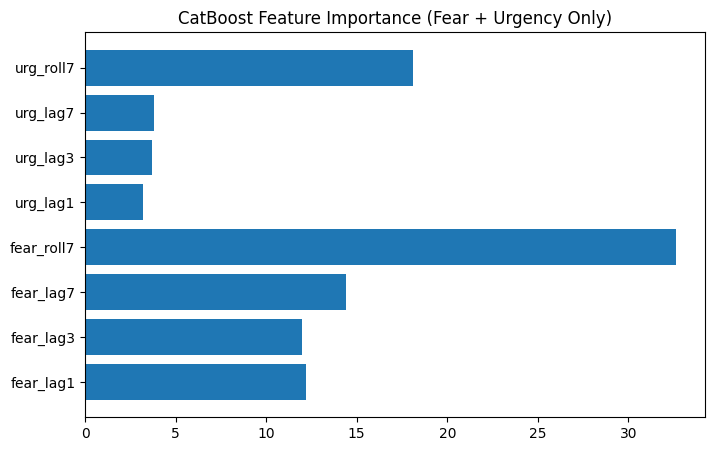

In [9]:
# ================================================================
# CATBOOST EARLY-WARNING MODEL (FEAR + URGENCY ONLY)
# ================================================================

import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ========================
# LOAD DATA
# ========================
gt = pd.read_csv("improved_h5n1_ground_truth.csv")
gt["date"] = pd.to_datetime(gt["date"]).dt.date
gt["date"] = pd.to_datetime(gt["date"])
gt["country"] = gt["country"].astype(str).str.strip()

stigma = pd.read_csv("tft/tft_part2_daily_stigma_fixed.csv")
stigma["date"] = pd.to_datetime(stigma["date"])
stigma["inferred_country"] = stigma["inferred_country"].astype(str).str.strip()

# ========================
# FULL DAILY GRID
# ========================
all_countries = stigma["inferred_country"].unique()
all_dates = pd.date_range(stigma["date"].min(), stigma["date"].max(), freq="D")

calendar = (
    pd.MultiIndex.from_product([all_dates, all_countries], names=["date","country"])
    .to_frame(index=False)
)

gt_daily = (
    gt.groupby(["date","country"], as_index=False)
      .agg({"fused_outbreak":"max"})
)

gt_full = calendar.merge(gt_daily, on=["date","country"], how="left")
gt_full["fused_outbreak"] = gt_full["fused_outbreak"].fillna(0).astype(int)

# ========================
# CREATE EARLY WARNING LABEL (30 DAYS BEFORE OUTBREAK)
# ========================
early_window = 30
gt_full = gt_full.sort_values(["country","date"])
gt_full["early_warning"] = 0

for c in gt_full["country"].unique():
    df = gt_full[gt_full["country"] == c]
    outbreak_dates = df[df["fused_outbreak"] == 1]["date"].values
    for od in outbreak_dates:
        mask = (df["date"] >= od - pd.Timedelta(days=early_window)) & \
               (df["date"] <  od)
        gt_full.loc[df.index[mask], "early_warning"] = 1

# ========================
# MERGE WITH STIGMA
# ========================
merged = stigma.merge(
    gt_full,
    left_on=["date","inferred_country"],
    right_on=["date","country"],
    how="left"
)

merged["early_warning"] = merged["early_warning"].fillna(0).astype(int)

# ========================
# FEATURE ENGINEERING (FEAR + URGENCY ONLY)
# ========================
merged = merged.sort_values(["inferred_country","date"])

# fear lags
for lag in [1,3,7]:
    merged[f"fear_lag{lag}"] = merged.groupby("inferred_country")["stigma_fear"].shift(lag)

# urgency lags
for lag in [1,3,7]:
    merged[f"urg_lag{lag}"] = merged.groupby("inferred_country")["stigma_urgency"].shift(lag)

# rolling windows
merged["fear_roll7"] = merged.groupby("inferred_country")["stigma_fear"].rolling(
    7, min_periods=1).mean().reset_index(0,drop=True)

merged["urg_roll7"] = merged.groupby("inferred_country")["stigma_urgency"].rolling(
    7, min_periods=1).mean().reset_index(0,drop=True)

# drop rows where lags are NaN
merged = merged.dropna().reset_index(drop=True)

# ========================
# MODEL INPUTS
# ========================
feature_cols = [
    "fear_lag1","fear_lag3","fear_lag7","fear_roll7",
    "urg_lag1","urg_lag3","urg_lag7","urg_roll7"
]

X = merged[feature_cols]
y = merged["early_warning"]

# ========================
# TRAIN/TEST SPLIT
# ========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=False
)

# ========================
# CLASS WEIGHTS FOR IMBALANCE
# ========================
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
class_weights = {0: 1, 1: pos_weight}

# ========================
# CATBOOST TRAINING
# ========================
model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=class_weights,
    iterations=500,
    depth=6,
    learning_rate=0.03,
    random_seed=42,
    verbose=False
)

train_pool = Pool(X_train, y_train)
test_pool  = Pool(X_test,  y_test)

model.fit(train_pool)

# ========================
# EVALUATION
# ========================
y_prob = model.predict_proba(test_pool)[:,1]

print("\n=== BASE THRESHOLD (0.5) ===")
print(classification_report(y_test, (y_prob > 0.5).astype(int)))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))

# ========================
# FIND OPTIMAL THRESHOLD (MAX F1)
# ========================
prec, rec, th = precision_recall_curve(y_test, y_prob)
best_idx = np.argmax(2*(prec*rec)/(prec+rec+1e-8))
best_threshold = th[max(best_idx-1, 0)]

print("\n=== OPTIMAL THRESHOLD ===")
print("Best threshold:", best_threshold)
print(classification_report(y_test, (y_prob >= best_threshold).astype(int)))

# ========================
# FEATURE IMPORTANCE
# ========================
importances = model.get_feature_importance()
plt.figure(figsize=(8,5))
plt.barh(feature_cols, importances)
plt.title("CatBoost Feature Importance (Fear + Urgency Only)")
plt.show()


# Cross-Correlation Lead/Lag Analysis (per country)


===== TOP COUNTRIES: FEAR LEADERS =====
        country  best_fear_lag_days  best_fear_corr
0     Australia                 -30             0.0
25     Mongolia                 -30             0.0
27        Nepal                 -30             0.0
28  Netherlands                 -30             0.0
29  North Korea                 -30             0.0
30         Oman                 -30             0.0
31     Pakistan                 -30             0.0
32  Philippines                 -30             0.0
33        Qatar                 -30             0.0
34      Romania                 -30             0.0

===== TOP COUNTRIES: URGENCY LEADERS =====
        country  best_urgency_lag_days  best_urgency_corr
0     Australia                    -30                0.0
25     Mongolia                    -30                0.0
27        Nepal                    -30                0.0
28  Netherlands                    -30                0.0
29  North Korea                    -30               

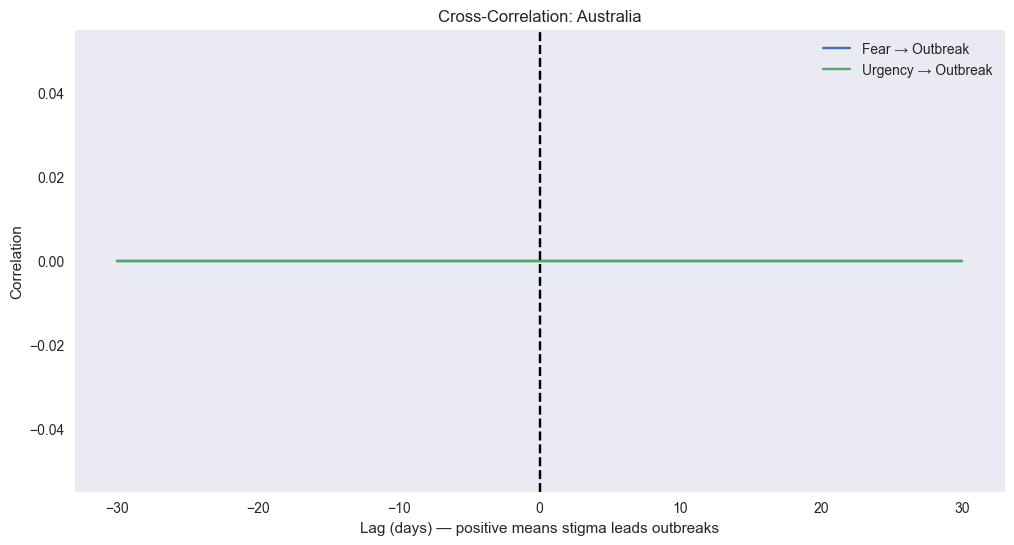

In [19]:
# ================================================================
# CROSS-CORRELATION ANALYSIS FOR FEAR & URGENCY (PER COUNTRY)
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate
from scipy.stats import zscore

plt.style.use("seaborn-v0_8")

# ========================
# LOAD DATA
# ========================
gt = pd.read_csv("improved_h5n1_ground_truth.csv")
gt["date"] = pd.to_datetime(gt["date"])
gt["country"] = gt["country"].astype(str).str.strip()

stigma = pd.read_csv("tft/tft_part2_daily_stigma_fixed.csv")
stigma["date"] = pd.to_datetime(stigma["date"])
stigma["inferred_country"] = stigma["inferred_country"].astype(str).str.strip()

# ========================
# BUILD FULL DATE × COUNTRY GRID
# ========================
all_countries = stigma["inferred_country"].unique()
all_dates = pd.date_range(stigma["date"].min(), stigma["date"].max(), freq="D")

calendar = (
    pd.MultiIndex.from_product([all_dates, all_countries], names=["date","country"])
    .to_frame(index=False)
)

# merge GT
gt_daily = gt.groupby(["date","country"], as_index=False).agg({"fused_outbreak": "max"})
gt_full = calendar.merge(gt_daily, on=["date","country"], how="left")
gt_full["fused_outbreak"] = gt_full["fused_outbreak"].fillna(0).astype(int)

# merge stigma
merged = calendar.merge(
    stigma,
    left_on=["date","country"],
    right_on=["date","inferred_country"],
    how="left"
)

merged["stigma_fear"]      = merged["stigma_fear"].fillna(0)
merged["stigma_urgency"]   = merged["stigma_urgency"].fillna(0)

merged = merged.merge(gt_full[["date","country","fused_outbreak"]],
                      on=["date","country"], how="left")

merged["fused_outbreak"] = merged["fused_outbreak"].fillna(0)

# ========================
# CROSS-CORRELATION FUNCTION
# ========================
def compute_ccf(x, y, max_lag=30):
    """
    Robust cross-correlation with full NaN protection.
    Positive lag = x leads y (early warning).
    """

    # Convert to numpy
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    # Replace NaNs with zeros BEFORE normalization
    x = np.nan_to_num(x, nan=0.0)
    y = np.nan_to_num(y, nan=0.0)

    # Safe z-normalization (avoid division by zero)
    x_std = x.std()
    y_std = y.std()
    if x_std == 0: x_std = 1e-6
    if y_std == 0: y_std = 1e-6

    x = (x - x.mean()) / x_std
    y = (y - y.mean()) / y_std

    corrs = []

    for lag in range(-max_lag, max_lag + 1):

        # Lag > 0 → x leads y
        if lag > 0:
            xs = x[:-lag]
            ys = y[lag:]
        # Lag < 0 → x lags y
        elif lag < 0:
            xs = x[-lag:]
            ys = y[:lag]
        # Lag = 0 → simultaneous
        else:
            xs = x
            ys = y

        # Ensure non-empty and enough points
        if len(xs) < 5 or len(ys) < 5:
            corrs.append(0.0)
            continue

        # If all values are constant or NaN → correlation undefined
        if np.all(np.isnan(xs)) or np.all(np.isnan(ys)):
            corrs.append(0.0)
            continue

        if xs.std() == 0 or ys.std() == 0:
            corrs.append(0.0)
            continue

        # Compute correlation safely
        try:
            corr = np.corrcoef(xs, ys)[0, 1]
            if np.isnan(corr):
                corr = 0.0
        except Exception:
            corr = 0.0

        corrs.append(corr)

    return np.array(corrs)



# ========================
# RUN PER-COUNTRY CCF ANALYSIS
# ========================
results = []

max_lag = 30  # days
lags = np.arange(-max_lag, max_lag+1)

for country in merged["country"].unique():

    df = merged[merged["country"] == country].sort_values("date").copy()

    fear_ccf    = compute_ccf(df["stigma_fear"], df["fused_outbreak"], max_lag=max_lag)
    urgency_ccf = compute_ccf(df["stigma_urgency"], df["fused_outbreak"], max_lag=max_lag)

    best_fear_lag    = lags[np.nanargmax(fear_ccf)]
    best_fear_corr   = np.nanmax(fear_ccf)

    best_urg_lag     = lags[np.nanargmax(urgency_ccf)]
    best_urg_corr    = np.nanmax(urgency_ccf)

    results.append({
        "country": country,
        "best_fear_lag_days": int(best_fear_lag),
        "best_fear_corr": float(best_fear_corr),
        "best_urgency_lag_days": int(best_urg_lag),
        "best_urgency_corr": float(best_urg_corr)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("best_fear_corr", ascending=False)

print("\n===== TOP COUNTRIES: FEAR LEADERS =====")
print(results_df[["country","best_fear_lag_days","best_fear_corr"]].head(10))

print("\n===== TOP COUNTRIES: URGENCY LEADERS =====")
print(results_df[["country","best_urgency_lag_days","best_urgency_corr"]].head(10))

# ========================
# PLOT EXAMPLE COUNTRY
# ========================
example_country = results_df.iloc[0]["country"]

dfc = merged[merged["country"] == example_country].sort_values("date")

fear_ccf = compute_ccf(dfc["stigma_fear"], dfc["fused_outbreak"], max_lag=max_lag)
urg_ccf  = compute_ccf(dfc["stigma_urgency"], dfc["fused_outbreak"], max_lag=max_lag)

plt.figure(figsize=(12,6))
plt.plot(lags, fear_ccf, label="Fear → Outbreak")
plt.plot(lags, urg_ccf, label="Urgency → Outbreak")
plt.axvline(0, color="black", linestyle="--")
plt.title(f"Cross-Correlation: {example_country}")
plt.xlabel("Lag (days) — positive means stigma leads outbreaks")
plt.ylabel("Correlation")
plt.legend()
plt.grid()
plt.show()


/opt/homebrew/lib/python3.11/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


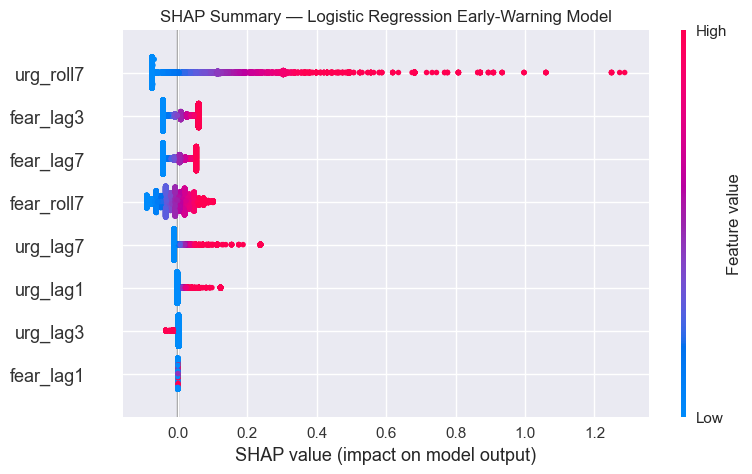

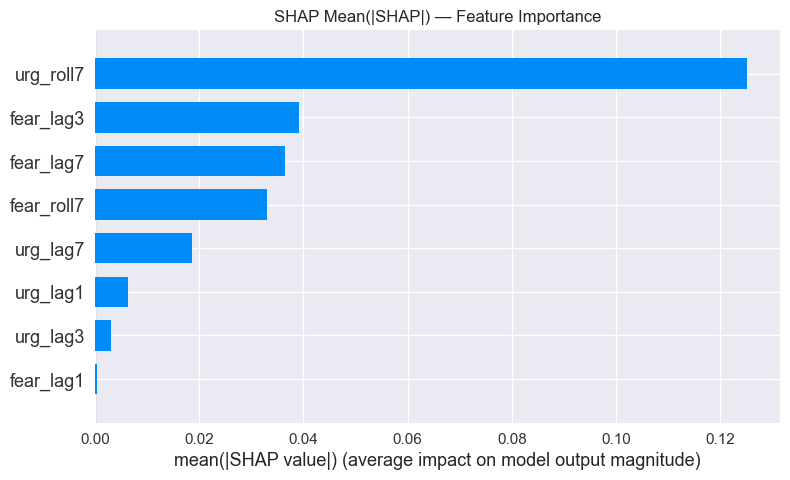

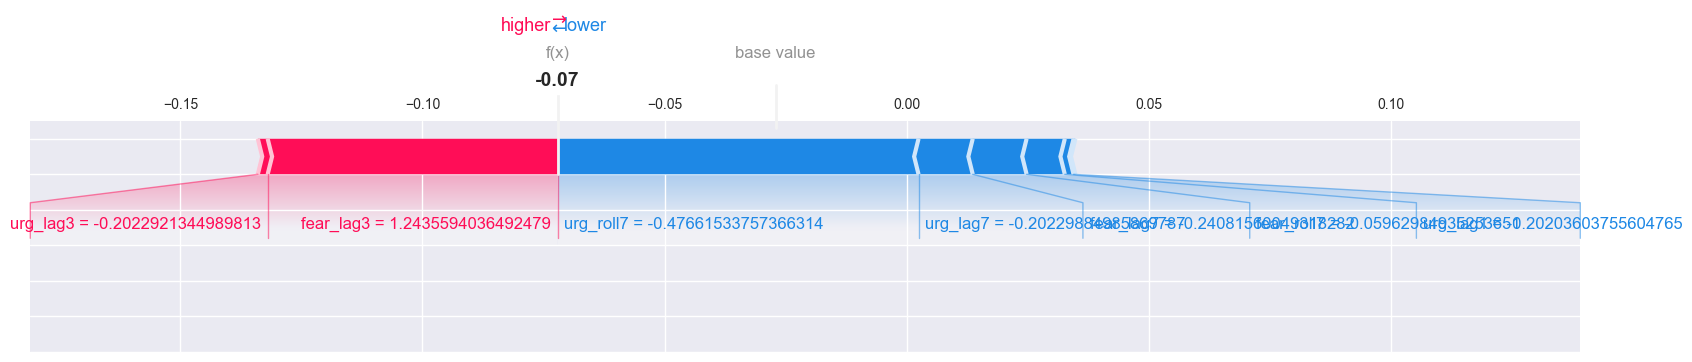


=== COUNTRY-LEVEL MEAN SHAP VALUES ===
            shap_fear_lag1  shap_fear_lag3  shap_fear_lag7  shap_fear_roll7  \
country                                                                       
Australia     2.742399e-07        0.010362       -0.002804        -0.000895   
Bahrain      -2.294397e-05        0.006385        0.000042         0.000775   
Bangladesh    3.502472e-05        0.005213       -0.004297         0.002892   
Bhutan        1.219539e-05        0.002202        0.005051         0.000431   
Brunei       -3.862312e-05        0.010349        0.007109        -0.001610   

            shap_urg_lag1  shap_urg_lag3  shap_urg_lag7  shap_urg_roll7  
country                                                                  
Australia        0.004073       0.000921       0.002227        0.037114  
Bahrain          0.004411       0.000940       0.001871        0.035474  
Bangladesh       0.004201       0.000290       0.001136        0.029544  
Bhutan           0.002418       0.00

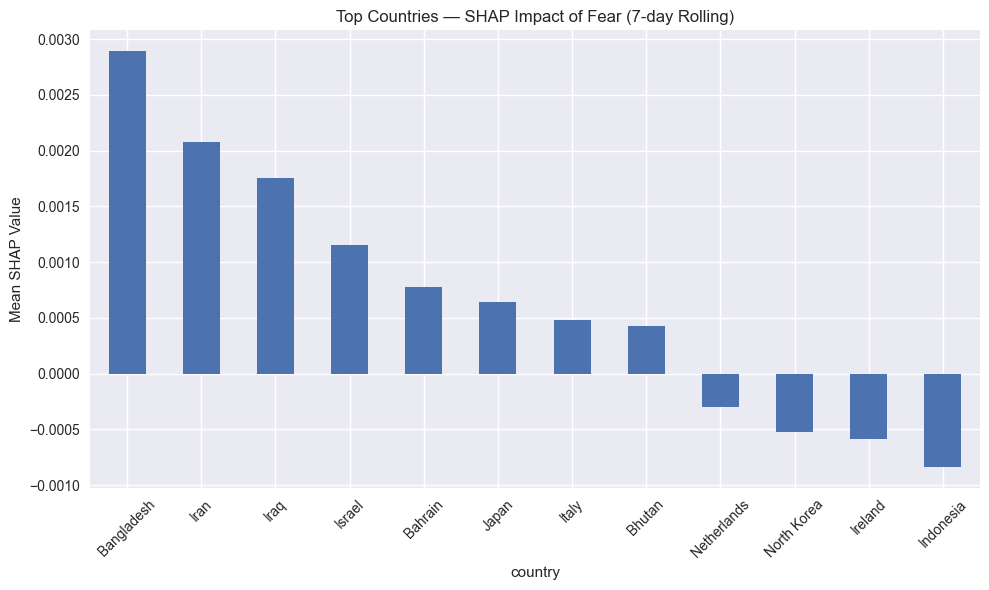

In [21]:
# ============================================================
# SHAP ANALYSIS FOR LOGISTIC REGRESSION — FEAR + URGENCY ONLY
# ============================================================

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.style.use("seaborn-v0_8")

# ---------------------------
# 1. Feature names from model
# ---------------------------
feature_names = [
    "fear_lag1","fear_lag3","fear_lag7","fear_roll7",
    "urg_lag1","urg_lag3","urg_lag7","urg_roll7"
]

X_train_np = X_train_s  # scaled train data
X_test_np  = X_test_s   # scaled test data

# ---------------------------
# 2. SHAP Explainer
# ---------------------------
explainer = shap.LinearExplainer(
    model,
    X_train_np,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_test_np)

# ---------------------------
# 3. Global summary plot
# ---------------------------
plt.figure(figsize=(9,6))
shap.summary_plot(shap_values, X_test_np, feature_names=feature_names, show=False)
plt.title("SHAP Summary — Logistic Regression Early-Warning Model")
plt.show()

# ---------------------------
# 4. Mean absolute importance
# ---------------------------
plt.figure(figsize=(8,5))
shap.summary_plot(
    shap_values,
    X_test_np,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP Mean(|SHAP|) — Feature Importance")
plt.show()

# ---------------------------
# 5. Force plot for a positive early-warning example
# ---------------------------
try:
    idx_pos = np.where(y_test.values == 1)[0][0]
    shap.force_plot(
        explainer.expected_value,
        shap_values[idx_pos, :],
        X_test_np[idx_pos, :],
        feature_names=feature_names,
        matplotlib=True
    )
except:
    print("No positive early-warning samples available for force plot.")

# ---------------------------
# 6. Country-level mean SHAP values
# ---------------------------

test_df = pd.DataFrame(X_test_np, columns=feature_names)
test_df["y_true"] = y_test.values
test_df["country"] = merged.loc[X_test.index, "country"].values

# compute SHAP means
for f in feature_names:
    test_df[f"shap_{f}"] = shap_values[:, feature_names.index(f)]

country_shap = test_df.groupby("country")[
    [f"shap_{f}" for f in feature_names]
].mean()

print("\n=== COUNTRY-LEVEL MEAN SHAP VALUES ===")
print(country_shap.head())

# ---------------------------
# 7. Plot top countries by fear_roll7 SHAP
# ---------------------------
top_fear = country_shap.sort_values("shap_fear_roll7", ascending=False).head(12)

plt.figure(figsize=(10,6))
top_fear["shap_fear_roll7"].plot(kind="bar")
plt.title("Top Countries — SHAP Impact of Fear (7-day Rolling)")
plt.ylabel("Mean SHAP Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
